In [29]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [30]:
df = pd.read_csv("/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [31]:
print(df.shape)

(10000, 14)


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [35]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [36]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [37]:
df.drop(columns = ['RowNumber','CustomerId','Surname'],inplace = True)

In [38]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [39]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

In [40]:
X = df.drop(columns = ["Exited"])
y = df["Exited"]
from sklearn.model_selection import train_test_split
X_train,X_test, Y_train, Y_test = train_test_split(X,y,test_size = 0.2, random_state = 1)

In [41]:
X_train

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
2694,628,29,3,113146.98,2,0,1,124749.08,True,False,True
5140,626,29,4,105767.28,2,0,0,41104.82,False,False,False
2568,612,47,6,130024.87,1,1,1,45750.21,True,False,False
3671,646,52,6,111739.40,2,0,1,68367.18,True,False,False
7427,714,33,8,122017.19,1,0,0,162515.17,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...
2895,621,47,7,107363.29,1,1,1,66799.28,True,False,True
7813,684,63,3,81245.79,1,1,0,69643.31,True,False,False
905,672,45,9,0.00,1,1,1,92027.69,False,False,False
5192,663,39,8,0.00,2,1,1,101168.90,False,False,False


In [42]:
from  sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [43]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]], shape=(8000, 11))

In [44]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [45]:
import tensorflow as tf

print(tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [46]:
model = Sequential()
model.add(Dense(10, activation = 'relu', input_dim = 11))
model.add(Dense(10, activation = 'relu', input_dim = 11))
model.add(Dense(1, activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [47]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

In [48]:
model.compile(loss = 'binary_crossentropy',optimizer= 'Adam', metrics=['accuracy'])

In [49]:
 history = model.fit(X_train_scaled,Y_train, epochs = 100, validation_split = 0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7914 - loss: 0.5213 - val_accuracy: 0.7975 - val_loss: 0.4834
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7984 - loss: 0.4580 - val_accuracy: 0.8050 - val_loss: 0.4518
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8134 - loss: 0.4328 - val_accuracy: 0.8206 - val_loss: 0.4302
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8266 - loss: 0.4145 - val_accuracy: 0.8325 - val_loss: 0.4111
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8392 - loss: 0.3988 - val_accuracy: 0.8381 - val_loss: 0.3937
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8458 - loss: 0.3847 - val_accuracy: 0.8419 - val_loss: 0.3804
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8500 - loss: 0.3739 - val_accuracy: 0.8462 - val_loss: 0.3702
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8498 - loss: 0.3664 - val_accu

In [50]:
model.layers[0].get_weights()

[array([[-0.28000733,  0.01663244, -0.18177968, -0.21209893, -0.02612223,
          0.11521485,  0.10039402,  0.02425497,  0.02164615,  0.07577287],
        [ 0.7147791 , -0.14297493, -0.55869675, -0.66239893,  0.02190079,
         -0.4244416 , -0.8458975 ,  0.44439694, -0.1178412 ,  0.27792934],
        [ 0.1085397 , -0.02281339,  0.20598154,  0.28001526,  0.17751175,
         -0.11688449, -0.09761824,  0.36621475,  0.08623939,  0.0505509 ],
        [-0.20042703, -0.71894157, -0.9484037 , -0.18965866,  0.1459636 ,
          0.12267861, -0.04370078, -0.3010578 , -0.44885665, -0.0108981 ],
        [ 0.93601894, -0.96161854, -0.02761305,  0.16564918,  1.0110173 ,
          0.07852793,  0.1240856 ,  0.1508726 ,  0.7196255 , -0.04791896],
        [ 0.32404304, -0.02378212, -0.05093855, -0.16550976, -0.06708882,
         -0.15019411,  0.0882079 ,  0.02463531,  0.04494471,  0.03587773],
        [ 0.37408528,  0.01680165, -0.05988392, -0.05632066,  0.14367963,
          0.37893376, -0.1989891

In [51]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [52]:
y_pred = np.where(y_log>0.5,1,0)

In [53]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,y_pred)

0.867

In [54]:
import matplotlib.pyplot as  plt

In [55]:
history.history

{'accuracy': [0.7914062738418579,
  0.7984374761581421,
  0.8134375214576721,
  0.8265625238418579,
  0.8392187356948853,
  0.8457812666893005,
  0.8500000238418579,
  0.8498437404632568,
  0.8506249785423279,
  0.8531249761581421,
  0.8540624976158142,
  0.8532812595367432,
  0.8542187213897705,
  0.8550000190734863,
  0.8560937643051147,
  0.8559374809265137,
  0.8567187786102295,
  0.856249988079071,
  0.8564062714576721,
  0.8568750023841858,
  0.8582812547683716,
  0.8596875071525574,
  0.8590624928474426,
  0.8590624928474426,
  0.8596875071525574,
  0.8607812523841858,
  0.8609374761581421,
  0.8614062666893005,
  0.8609374761581421,
  0.8626562356948853,
  0.8634374737739563,
  0.8609374761581421,
  0.8631250262260437,
  0.8631250262260437,
  0.8614062666893005,
  0.86328125,
  0.862500011920929,
  0.8626562356948853,
  0.8631250262260437,
  0.8628125190734863,
  0.8639062643051147,
  0.8642187714576721,
  0.8626562356948853,
  0.864062488079071,
  0.8637499809265137,
  0.86468

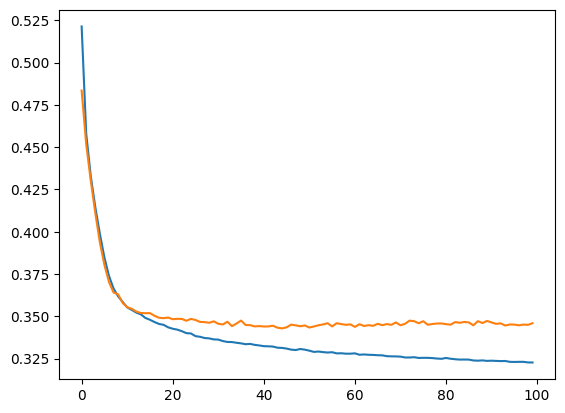

In [56]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

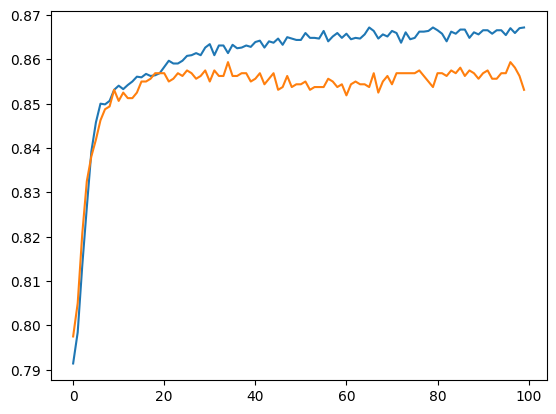

In [59]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])